In [23]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  # looks for a "src" sibling/parent of the notebook


[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [24]:
import os, json, time, math, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- data utils ---
from src.data.prepare_dataset import (
    build_pairs_for_split,
    build_all_train_pairs,
    assert_dataset_layout,
    sanity_check_sample_alignment,
)
from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

from src.models.unet_exp.unetplus import UNetBaselinePlus

# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = Path("./runs/dpcn_cbam_unet")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SEED = 1337
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True


In [25]:
data_dir = "../data/raw/DRIVE"

train_pairs = build_pairs_for_split(dataset_root=data_dir, split="training", label_folder="1st_manual")
test_pairs  = build_pairs_for_split(dataset_root=data_dir, split="test",     label_folder="1st_manual")

train_loader, test_loader = make_loaders(
    train_pairs=train_pairs,
    val_pairs=test_pairs,      # <- this becomes the second loader we call "test_loader"
    image_size=512,
    batch_size=2,
    num_workers=4,             # Windows notebook → keep 0
    seed=1337,
    strict_fov=True,
    augs_train= None,
    augs_val = None
    #augs_train=get_train_augs(512),   # real augmentations
    #augs_val=get_val_augs(512),       # deterministic preprocessing (no random augs)
)

In [26]:
# ---- model instantiation (pure UNet) ----
# If you estimated 'p' earlier via estimate_class_weights, use it; else default to 0.10
pos_prior = p if 'p' in locals() else 0.10

model_core = UNetBaselinePlus(
    in_channels=1,
    base_ch=64,
    bottleneck_dropout=0.10,
    init_pos_prior=pos_prior
).to(DEVICE)

# param count
print(sum(x.numel() for x in model_core.parameters() if x.requires_grad)/1e6, "M params")

30.339265 M params


In [27]:
from src.training.loss_functions import DiceBCEComplementLoss
import torch

# (optional) estimate class weights from a few batches to handle heavy imbalance
def estimate_class_weights(loader, max_batches=20):
    with torch.no_grad():
        s = 0.0; n = 0
        for i, b in enumerate(loader):
            s += b["mask"].float().mean().item()  # foreground fraction in [0,1]
            n += 1
            if i+1 >= max_batches: break
    p = max(1e-6, min(1-1e-6, s / max(1, n)))      # foreground prior
    w1 = 1.0 / p                                    # weight FG inversely to its freq
    w0 = 1.0 / (1.0 - p)                            # weight BG inversely to its freq
    # normalize so w0 + w1 ≈ 2 (keeps scale stable)
    s2 = w0 + w1
    w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
    return w0, w1, p

w0, w1, p = estimate_class_weights(train_loader, max_batches=20)
print(f"~ foreground prior p ≈ {p:.5f} | class weights -> w0={w0:.3f}, w1={w1:.3f}")

loss_fn = DiceBCEComplementLoss(
    w0=w0, w1=w1,
    dice_weight=0.5,         # tune (e.g., 0.6 Dice / 0.4 BCE)
    bce_weight=0.5,
    exact_equation=False,    # keep False so the BCE term is minimized (not added)
    reduction="mean",
)

~ foreground prior p ≈ 0.08350 | class weights -> w0=0.167, w1=1.833


In [28]:
def train_one_epoch(model, loader, optimizer, scaler, loss_fn):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)  # [B,1,H,W]
        y = batch["mask"].to(DEVICE,  non_blocking=True)  # [B,1,H,W]

        # Optional: mask labels outside FOV if present (keeps loss fair)
        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNET: no fov passed
            loss   = loss_fn(logits, y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total += loss.item() * x.size(0)
        n     += x.size(0)
    return total / max(1, n)

@torch.no_grad()
def validate_loss_only(model, loader, loss_fn):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["mask"].to(DEVICE,  non_blocking=True)

        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNET
            loss   = loss_fn(logits, y)

        total += loss.item() * x.size(0)
        n     += x.size(0)
    return total / max(1, n)

In [29]:
import json, time, math
from torch.optim.lr_scheduler import LambdaLR

# --- optimizer / scaler / scheduler ---
optimizer = torch.optim.AdamW(model_core.parameters(), lr=3e-4, weight_decay=1e-4)
scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))

EPOCHS = 100
warmup_epochs = 5

def lr_lambda(e):
    if e < warmup_epochs:
        return (e + 1) / warmup_epochs
    progress = (e - warmup_epochs) / max(1, EPOCHS - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

best_val = float("inf")

# --- lists to collect losses for plotting later ---
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS+1):
    print(f"----- EPOCH {epoch} -----")
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.time()

    tr_loss  = train_one_epoch(model_core, train_loader, optimizer, scaler, loss_fn)
    val_loss = validate_loss_only(model_core, test_loader, loss_fn)
    scheduler.step()

    if DEVICE == "cuda": torch.cuda.synchronize()
    print(f"[{epoch:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
          f"lr={optimizer.param_groups[0]['lr']:.3e} time={(time.time()-t0):.1f}s")

    # record
    train_losses.append(float(tr_loss))
    val_losses.append(float(val_loss))

    # checkpoints
    torch.save(model_core.state_dict(), SAVE_DIR / "last.pth")
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_core.state_dict(), SAVE_DIR / "best.pth")
        with open(SAVE_DIR / "best.json","w") as f:
            json.dump({"epoch": epoch, "val_loss": float(val_loss)}, f, indent=2)

----- EPOCH 1 -----
[001] train=2.1583 val=0.7454 lr=1.200e-04 time=40.6s
----- EPOCH 2 -----
[002] train=0.7171 val=0.5618 lr=1.800e-04 time=18.2s
----- EPOCH 3 -----
[003] train=0.5990 val=0.6990 lr=2.400e-04 time=18.3s
----- EPOCH 4 -----
[004] train=0.5119 val=0.4504 lr=3.000e-04 time=18.9s
----- EPOCH 5 -----
[005] train=0.4713 val=0.4432 lr=3.000e-04 time=18.9s
----- EPOCH 6 -----
[006] train=0.4517 val=0.4205 lr=2.999e-04 time=18.6s
----- EPOCH 7 -----
[007] train=0.5029 val=0.3786 lr=2.997e-04 time=20.3s
----- EPOCH 8 -----
[008] train=0.4250 val=0.3812 lr=2.993e-04 time=19.5s
----- EPOCH 9 -----
[009] train=0.4202 val=0.3804 lr=2.987e-04 time=18.4s
----- EPOCH 10 -----
[010] train=0.4310 val=0.3594 lr=2.980e-04 time=18.7s
----- EPOCH 11 -----
[011] train=0.3972 val=0.3562 lr=2.971e-04 time=18.0s
----- EPOCH 12 -----
[012] train=0.3895 val=0.3747 lr=2.960e-04 time=18.9s
----- EPOCH 13 -----
[013] train=0.3983 val=0.3514 lr=2.948e-04 time=18.8s
----- EPOCH 14 -----
[014] train=0

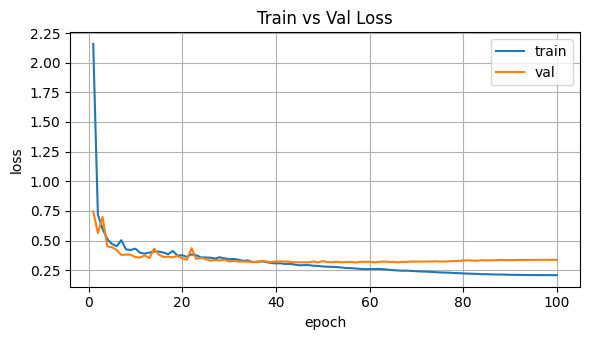

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3.5))
plt.plot(range(1, len(train_losses)+1), train_losses, label="train")
plt.plot(range(1, len(val_losses)+1),   val_losses,   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True); plt.legend()
plt.title("Train vs Val Loss")
plt.tight_layout()
plt.show()


In [31]:
# load best
model_core.load_state_dict(torch.load(SAVE_DIR / "best.pth", map_location=DEVICE))
model_for_eval = model_core.eval()

# run your evaluation utility
evaluate_and_print(model_for_eval, test_dataloader=test_loader, device=DEVICE, threshold=0.5, compute_auc=True)

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7936
Specificity    : 0.9829
Dice           : 0.8000
Accuracy       : 0.9666
IoU            : 0.6670
Precision      : 0.8106
FPR            : 0.0171
FDR            : 0.1894
clDice         : 0.8022
Dice_thin      : 0.5104
Dice_thick     : 0.6710
ROC_AUC        : 0.9804
PR_AUC         : 0.8832
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7910
Specificity    : 0.9829
F1/Dice        : 0.8005
Accuracy       : 0.9666
IoU            : 0.6674
Precision      : 0.8103
FPR            : 0.0171
FDR            : 0.1897
ROC_AUC        : 0.9800
PR_AUC         : 0.8813


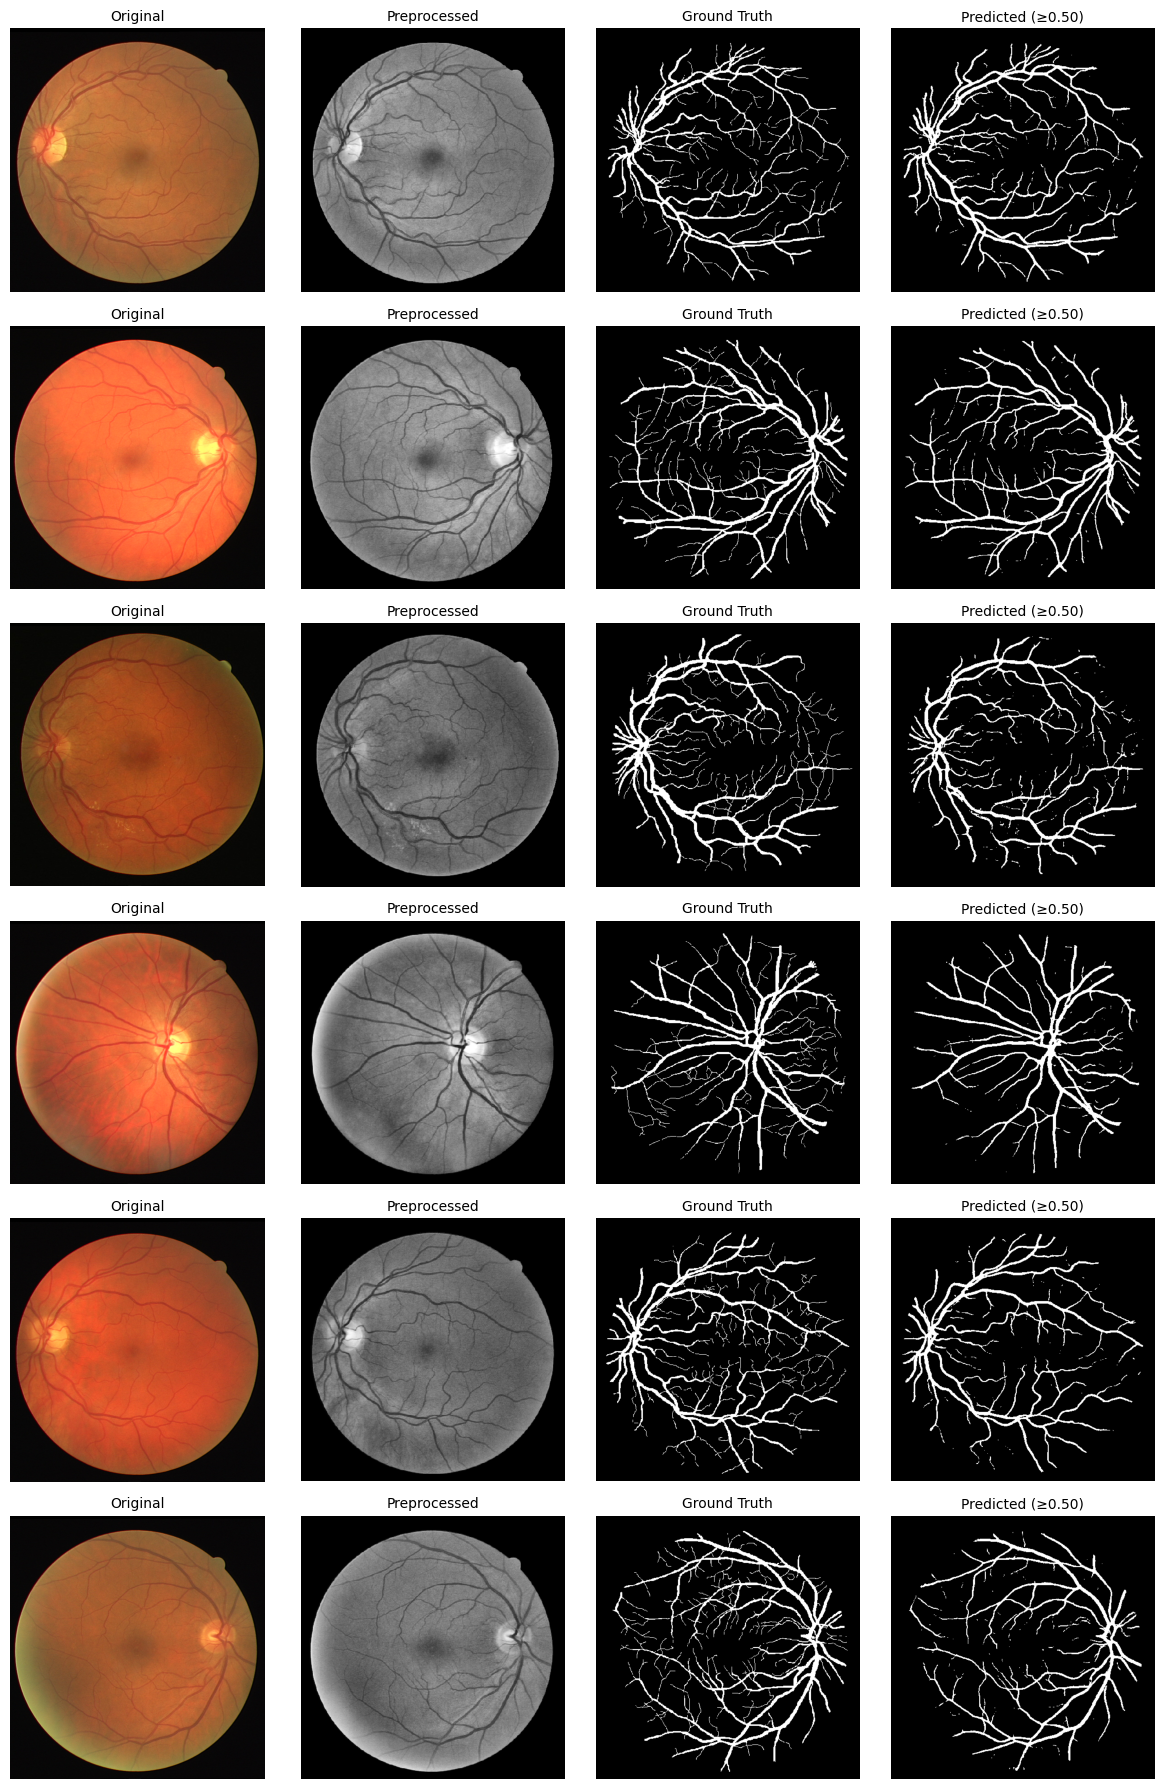

In [32]:
visualize_samples(
    model=model_for_eval,
    dataloader=test_loader,
    n_rows=6,
    device=DEVICE,
    threshold=0.5,
    clamp_pred_with_fov=True,
    figsize_per_row=(12, 3),
)